<a href="https://colab.research.google.com/github/DavidSenseman/BIO1173/blob/main/BIO1173_Assignment_01_BinaryClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- BIO1173_ASSIGNMENT_01_BINARY:Rev 1 -->

---------------------------
**COPYRIGHT NOTICE:** This Jupyterlab Notebook is a Derivative work of [Jeff Heaton](https://github.com/jeffheaton) licensed under the Apache License, Version 2.0 (the "License"); You may not use this file except in compliance with the License. You may obtain a copy of the License at

> [http://www.apache.org/licenses/LICENSE-2.0](http://www.apache.org/licenses/LICENSE-2.0)

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.

------------------------

# **BIO 1173: Intro Computational Biology**

**Assignment 1: Neural Networks for Analysis of Tabular Data**

* Instructor: [David Senseman](mailto:David.Senseman@utsa.edu), [Department of Integrative Biology](https://sciences.utsa.edu/integrative-biology/), [UTSA](https://www.utsa.edu/)



# **READ CAREFULLY**

The **_first_**  digit in your myUTSA ID (e.g. "abc123") will determine which dataset you are to analyze for this assignment and which type of neural network (i.e. classification or regression) you will need to construct. For example, if your myUTSA ID was **vue682**, then your first digit is the number `6`.

**---WARNING------WARNING------WARNING------WARNING------WARNING------WARNING---**

You are **not** free to choose any dataset for this assignment. If analyze the wrong dataset, your assignment will **NOT BE GRADED** and you will automatically receive a **`1`**. If you are uncertain which dataset you should be working on, contact your Instructor for help. Remember, your score in this assignment will have a large impact on your course grade so please be careful.


| First Digit myUTSA ID    | Dataset to Analyze      | Neural Network Type
--------------------------|-------------------------|-----------------
0                         | Hepatitis               | Binary Classification
1                         | Coimbra Breast Cancer   | Binary Classification
2                         | Parkinson Speech        | Binary Classification
3                         | Indian Liver            | Binary Classification
4                         | Fetal Health            | Multiclass Classification
5                         | Dermatology             | Multiclass Classification
6                         | Maternal Health         | Multiclass Classification
7                         | Bone Marrow Transplant  | Regression
8                         | German Breast Cancer    | Regression
9                         | Diabetes Progression    | Regression

#### **NOTE: You can only use this Colab notebook if the first digit of your _myUTSA_ ID  is between `0` and `3`.**

# **The Purpose of Assignments**

In this course, **_Assignments_** are designed to help me (and you) assess your ability to transfer knowledge gained in completing class coding exercises to solving more realistic problems.

Assignments play a pivotal role in reinforcing your learning, as they require you to apply theoretical concepts to practical scenarios. This helps solidify your understanding and enhances your problem-solving skills. By tackling these assignments independently, you develop critical thinking and the ability to synthesize information from various sources. Moreover, assignments encourage you to explore topics more deeply, fostering intellectual curiosity and promoting a deeper engagement with the subject matter. Ultimately, these assignments are not just a measure of your learning, but a means to equip you with the skills needed for real-world applications and future challenges.

## **MAKE A COPY OF THIS NOTEBOOK!**

For your assignment to be graded, you **must** make a copy of this Colab notebook in your GDrive and use this copy as your worksheet.

## Google CoLab Instructions

You MUST run the following code cell to get credit for this class lesson. By running this code cell, you will map your GDrive to /content/drive and print out your Google GMAIL address. Your Instructor will use your GMAIL address to verify the author of this class lesson.

In [ ]:
# YOU MUST RUN THIS CELL FIRST

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    from google.colab import auth
    auth.authenticate_user()
    Colab = True
    print("Note: using Google CoLab")
    import requests
    gcloud_token = !gcloud auth print-access-token
    gcloud_tokeninfo = requests.get('https://www.googleapis.com/oauth2/v3/tokeninfo?access_token=' + gcloud_token[0]).json()
    print(gcloud_tokeninfo['email'])
except:
    print("**WARNING**: Your GMAIL address was **not** printed in the output below.")
    print("**WARNING**: You will NOT receive credit for this assignment.")
    Colab = False

Mounted at /content/drive
Note: using Google CoLab
david.senseman@gmail.com


## Test Your Keys

Run the next cell to test whether your `myUTSA_ID` and your `BIO1173_Key` are correctly installed in your Colab Secrets. You will need to have both keys correctly installed in your Colab Secrets in order to submit your work for grading using Electronic Submission.

In [ ]:
# @title Test Your Keys

from google.colab import userdata
import os

# Check if myUTSA_ID is properly loaded
try:
    # 1. Get the key from Secrets
    myUTSA_ID = userdata.get('myUTSA_ID')

    # 2. Set it as an environment variable
    os.environ['myUTSA_ID'] = myUTSA_ID

    # print("myUTSA_ID is loaded and environment variable set successfully!")
    print(f"myUTSA_ID: {myUTSA_ID}")

except Exception as e:
    print(f"Error loading myUTSA_ID: {e}")
    print("Please set your myUTSA_ID in Google Colab:")
    print("1. Go to Secrets in the left sidebar (key icon)")
    print("2. Create a new secret named 'myUTSA_ID'")
    print("3. Paste your myUTSA_ID and toggle 'Notebook access' on")

# Check if BIO1173 key is properly loaded
try:
    # 1. Get the key from Secrets
    BIO1173_KEY = userdata.get('BIO1173_KEY')

    # 2. Set it as an environment variable
    os.environ['BIO1173_KEY'] = BIO1173_KEY

    #print("BIO1173 key loaded and environment variable set successfully!")
    print(f"BIO1173_KEY: {BIO1173_KEY}")

except Exception as e:
    print(f"Error loading BIO1173 key: {e}")
    print("Please set your BIO1173 key in Google Colab:")
    print("1. Go to Secrets in the left sidebar (key icon)")
    print("2. Create a new secret named 'BIO1173_KEY'")
    print("3. Paste your BIO1173 key and toggle 'Notebook access' on")



myUTSA_ID: gie856
BIO1173_KEY: BIO1173-F26-00-UUU-5ST-X8R


If you have correctly installed your myUTSA id in your Colab Secrets, you should see something _similar_ to following but with your information:
```text
myUTSA_ID: abc123
BIO1173_KEY: BIO1173-F26-04-999-ABC-DEF
```
However, if you see an error message, you will need to fix this problem before you can submit your lesson for grading. Ask your Instructor or TA for help if you can't resolve the problem yourself --- that's what they are here for, to help you with course problems.

# **Assignment 1: Binary Classification**

**Assignment_01** is specifically designed to assess your ability to write the Python/PyTorch code necessary to build neural networks that can analyze tabular data stored in a Pandas DataFrame. These analyzes include: (1) binary classification, (2) multiclass classification and (3) regression.

You should use this Colab notebook **only** if the first digit in your myUTSA ID is between `0` and `3`. If that is correct, you have been assigned to perform **binary classification**.

Unlike your class lessons, you will **not** be given examples that you can use to simply copy-and-paste code. Rather, you will be given a problem to solve and it will be up to you to use code snippets that you have been given previously to solve different aspects of this assignment. And unlike your class lessons, your will **not** be given the correct output. In other words, this assignment is basically how you would solve an actual biomedical problem.

## **---AI WARNING---AI WARNING---AI WARNING---**

You are **NOT** allowed to use AI anywhere in your assignment. If you use AI you will receive a grade of only **1** out of 100 for this assignment. In other words, you will fail your assignment if you use AI.

If you encounter an error it probably means that you didn't read the instructions carefully. Your Instructor and TA's are here to help you fix any errors that you encounter. Don't lose a good grade in this course by using AI.

# **Binary Classification by Neural Networks**
**Binary classification** of tabular data is a type of supervised learning task where the goal is to categorize observations into one of two possible classes based on their attributes. Examples include:
1. **Disease Diagnosis:**
   - Does the patient have diabetes? (Yes/No)
   - Is this breast tumor malignant? (Yes/No)
   - Does the patient have hypertension? (Yes/No)
   - Is the patient infected with COVID-19? (Yes/No)
2. **Medical Outcomes:**
   - Will the patient survive after a heart attack? (Yes/No)
   - Will the patient respond positively to a specific treatment? (Yes/No)
   - Does the patient have a higher risk of developing heart disease? (Yes/No)
3. **Medical Conditions and Symptoms:**
   - Is the patient experiencing symptoms of depression? (Yes/No)
   - Does the patient have sleep apnea? (Yes/No)
   - Is the patient at risk for osteoporosis? (Yes/No)
   - Does the patient have a genetic predisposition to a certain condition? (Yes/No)
4. **Medical Procedures:**
   - Is surgery recommended for this patient? (Yes/No)
   - Does the patient need a blood transfusion? (Yes/No)
   - Is the patient a candidate for a particular clinical trial? (Yes/No)

## **Descriptions of Data Sets for Binary Classification**

This section describes the various datasets, information for downloading them, and what variable(s) your network should predict. Remember, you do **not** earn and credit if you analyze the wrong dataset. Pay particular attention to the **output** variable for Binary Classification because this column will contain the `Y- values` for your assigned dataset. You will need to know the name of the output feature when you are constructing yor X- and Y-feature vectors.



-----------------------------------------

## **Hepatitis Disease Classification - 1st myUTSA Digit = 0**

#### **Filename:** `hepatitis.csv`
#### **Output Variable (target column):** `CLASS`


### **Hepatitis Disease Classification Dataset**

The Hepatitis Disease Classification dataset contains patient records and clinical features used to predict the presence of hepatitis. The dataset includes demographic information and various liver function test results.

#### Features:
1. **AGE**: Age of the patient.
2. **SEX**: Gender of the patient (Male/Female).
3. **STEROID**: Use of steroids (Yes/No).
4. **ANTIVIRALS**: Use of antiviral medication (Yes/No).
5. **FATIGUE**: Presence of fatigue (Yes/No).
6. **MALAISE**: Presence of malaise (Yes/No).
7. **ANOREXIA**: Presence of anorexia (Yes/No).
8. **LIVER_BIG**: Size of the liver (Big/Not Big).
9. **LIVER_FIRM**: Firmness of the liver (Firm/Not Firm).
10. **SPLEEN_PALPABLE**: Palpability of the spleen (Yes/No).
11. **SPIDERS**: Presence of spider angiomas (Yes/No).
12. **ASCITES**: Presence of ascites (Yes/No).
13. **VARICES**: Presence of varices (Yes/No).
14. **BILIRUBIN**: Bilirubin levels (mg/dL).
15. **ALK_PHOSPHATE**: Alkaline phosphatase levels (IU/L).
16. **SGOT**: Serum Glutamic-Oxaloacetic Transaminase (AST) levels (IU/L).
17. **ALBUMIN**: Albumin levels (g/dL).
18. **PROTIME**: Prothrombin time (seconds).
19. **HISTOLOGY**: Histological examination result (Yes/No).

#### Target (y variable):
**CLASS** (class labels):
* **0**: No hepatitis
* **1**: Hepatitis

-----------------------------------------

## **Coimbra Breast Cancer - 1st myUTSA Digit = 1**

#### **Filename:** `Coimbra_breast_cancer_dataset.csv`
#### **Output Variable (target column):** `Class`


### **Coimbra Breast Cancer Dataset**

The Coimbra Breast Cancer dataset contains clinical features observed or measured for patients with breast cancer and healthy controls. The dataset includes anthropometric data and parameters typically gathered in routine blood analysis. Each patient record is described by 9 features and a binary dependent variable indicating the presence or absence of breast cancer.

#### Features:
1. **Age**: Age of the patient (years).
2. **BMI**: Body Mass Index (kg/m²).
3. **Glucose**: Glucose levels (mg/dL).
4. **Insulin**: Insulin levels (µU/mL).
5. **HOMA**: Homeostatic Model Assessment (HOMA).
6. **Leptin**: Leptin levels (ng/mL).
7. **Adiponectin**: Adiponectin levels (µU/mL).
8. **Resistin**: Resistin levels (ng/mL).
9. **MCP1**: Monocyte Chemoattractant Protein-1 levels (pg/dL).

#### Target (y variable):
**Class** (class labels):
* **Breast_Cancer**
* **Healthy**

## **Parkinson Speech Dataset - 1st myUTSA Digit = 2**

#### **Filename:**`Parkinson_speech.csv`
#### **Output Variable (Y values):** `class`

### **Parkinson Speech Dataset**

The Parkinson Speech dataset contains voice recordings from patients with Parkinson's Disease and healthy controls. The dataset includes various voice parameters and is used to classify the presence of Parkinson's Disease.

#### Features:
1. **Subject**: Unique identifier for each subject.
2. **Age**: Age of the subject.
3. **Gender**: Gender of the subject (0: Male, 1: Female).
4. **Test_time**: Time since recruitment into the trial (days).
5. **Motor_UPDRS**: Clinician’s motor UPDRS score.
6. **Total_UPDRS**: Clinician’s total UPDRS score.
7. **Jitter (%)**: Measure of variation in fundamental frequency.
8. **Jitter (Abs)**: Absolute measure of jitter.
9. **Jitter. RAP**: Jitter relative average perturbation.
10. **Jitter. PPQ5**: Jitter period perturbation quotient.
11. **Jitter. DDP**: Jitter difference to the previous period.
12. **Shimmer**: Measure of variation in amplitude.
13. **Shimmer (dB)**: Shimmer in decibels.
14. **Shimmer. APQ3**: Shimmer amplitude perturbation quotient.
15. **Shimmer. APQ5**: Shimmer amplitude perturbation quotient.
16. **Shimmer. APQ11**: Shimmer amplitude perturbation quotient.
17. **Shimmer. DDA**: Shimmer difference to the previous amplitude.
18. **NHR**: Harmonic-to-noise ratio.
19. **HNR**: Harmonic-to-noise ratio.
20. **RPDE**: Recurrence period density entropy.
21. **DFA**: Detrended fluctuation analysis.
22. **PPE**: Pitch period entropy.

#### Target (y variable):
**class** (class labels)
* **0**: Healthy
* **1**: Parkinson's Disease

----------------------------------------

## **Indian Liver Patient Dataset - 1st myUTSA Digit = 3**

#### **Filename:** Indian_Liver_Patient_Dataset.csv`
#### **Output Variable (Y values):** `Selector`


### **Indian Liver Patient Dataset**

The Indian Liver Patient Dataset contains patient records and clinical features used to predict the presence of liver disease. The dataset includes demographic information and various biochemical markers.

#### Features:
1. **Age**: Age of the patient (years).
2. **Gender**: Gender of the patient (Male/Female).
3. **TB**: Total Bilirubin levels (mg/dL).
4. **DB**: Direct Bilirubin levels (mg/dL).
5. **Alkphos**: Alkaline Phosphatase levels (IU/L).
6. **SGPT**: Serum Glutamic-Pyruvic Transaminase (ALT) levels (IU/L).
7. **SGOT**: Serum Glutamic-Oxaloacetic Transaminase (AST) levels (IU/L).
8. **TP**: Total Proteins (g/dL).
9. **ALB**: Albumin levels (g/dL).
10. **AG_Ratio**: Albumin/Globulin ratio.

#### Target (y variable):
**Selector** (class labels)
* **0:** No liver disease
* **1:** Diseased liver

# **General Instructions**

To make the assignment more manageable, you will given a number of specific steps to perform. To help guide you in writing your code, you will be given a specific example in a particular class lesson that you can use for a reference. For example, in **Step 1: Download and Extract Data** you are given **REF: Class_01_6: Examples 1 & 2**. That means Examples 1 and 2 in `Class_01_6` provide code that you can use to complete that step of this assignment.

### **Variable Names**

In writing your code for this assignment, you are free to give your variables any name that makes sense to you. This includes the name of the DataFrame that holds your data. When you `copy-and-paste` code from earlier Class assignments, you always have to edit the name of the DataFrame to match the name you select for this assignment in **Step 1**.

When it has been necessary to give an example that includes a DataFrame name, the DataFrame has been called simply `df` without any prefix. You will need to edit any variable names that you copy-and-paste from code examples to match the actual name you give to your DataFrame in **Step 1**.

### **Can I Use AI?**

**You can NOT use AI to help you complete this assignment**. If you use AI you will automatically receive a grade of `1` point (out of a possible 100 points) and you will fail this assignment. Since you are only allowed 1 submission, you will not be given a second chance. A significant pedagolical component of assignments in this course is to see if you can carefully read instructions. If you can't figure out how to solve a coding error, get help from your course Instructor and/or your course TA's.

### Create Custom Function

The cell below creates a custom function needed for this assignment. If you don't run this cell, you will receive errors later when you try to run some cells.

In [ ]:
# Create function for this lesson

# ------------------------------------------------------------------------
# 0️⃣  Create hms_string()
# ------------------------------------------------------------------------

# Simple function to print out elasped time
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return "{}:{:>02}:{:>05.2f}".format(h, m, s)

## **Step 1: Download and Extract Data**

**REF: Class_01_6: Example 1**

In the cell below, write the code to download your assigned datafile from the course server and create a `Pandas` DataFrame to store your data. Are are free to use any name for your DataFrame, just make sure to keep it consistent throughout the assignment. In this assignment the name `df` will be used for any examples given in the instructions.

After you download your datafile, use the `df.head()` method to display the contents.

**Code Hints:**

1. When using the command `pd.read_csv()` the file separator argument `sep` will be always be a comma **`,`**, **not** a tab.

2. You can **only** use the assigned dataset downloaded from the course file server https://biologicslab.co/BIO1173/data/, even if you happy to find a dataset with the same name at a different web location.

**If you don't download your assigned datafile from the course file server, you will receive a score of `1` point out of 100.**

3. Use this code to set your display settings:
```text
# Set max columns and max rows
pd.set_option('display.max_columns', df.shape[1])
pd.set_option('display.max_rows', 8)
```



In [ ]:
# @title Step 1: Download and Extract Data

# @title Example 1: Read a data file stored on the course HTTPS server

import pandas as pd

# Read data file using Pandas read_csv() function
df = pd.read_csv("https://biologicslab.co/BIO1173/data/hepatitis.csv",
                  sep=',',  # define the separator as a tab
                  na_values=["?", "NA", "null", ""])

# Set max columns and max rows
pd.set_option('display.max_columns', df.shape[1])
pd.set_option('display.max_rows', 8)

# Print out the first 5 records using the head() method
df.head()

,CLASS,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER_BIG,LIVER_FIRM,SPLEEN_PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK_PHOSHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
0,1,30,Female,1,2,2,2,2,1,2,2,2,2,2,1.0,85.0,18,4.0,62,1
1,1,50,Male,1,2,1,2,2,1,2,2,2,2,2,0.9,135.0,42,3.5,62,1
2,1,78,Male,2,2,1,2,2,2,2,2,2,2,2,0.7,96.0,32,4.0,62,1
3,1,31,Male,2,1,2,2,2,2,2,2,2,2,2,0.7,46.0,52,4.0,80,1
4,1,34,Male,2,2,2,2,2,2,2,2,2,2,2,1.0,105.0,200,4.0,62,1


If your code is correct you should see a table with a relatively large number of columns that may very well extend beyond the right edge of your notebook display.

## **Step 2: Print Summary Statistics**

**REF: Class_01_6: Example 3**

In the cell below use `df.describe()` to print put the summary statistics of your DataFrame.  

**Code Hints:**

Use this code to set your print output:
```text
# Set max columns and max rows
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 8)
```


In [ ]:
# @title  Step 2: Print summary statistics

import pandas as pd

# Set max columns and max rows
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 8)

# Describe() method with df_eg
df.describe()

,CLASS,AGE,STEROID,ANTIVIRALS,FATIGUE,MALAISE,...,BILIRUBIN,ALK_PHOSHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,...,155.000000,150.000000,155.000000,155.000000,155.000000,155.000000
mean,0.793548,41.200000,1.509677,1.845161,1.348387,1.600000,...,1.422581,105.273333,85.896774,3.815484,61.916129,1.451613
std,0.406070,12.565878,0.501527,0.362923,0.478004,0.491486,...,1.189377,47.177929,88.478934,0.616772,17.193685,0.499266
min,0.000000,7.000000,1.000000,1.000000,1.000000,1.000000,...,0.300000,26.000000,14.000000,2.100000,0.000000,1.000000
25%,1.000000,32.000000,1.000000,2.000000,1.000000,1.000000,...,0.800000,78.000000,32.500000,3.500000,57.000000,1.000000
50%,1.000000,39.000000,2.000000,2.000000,1.000000,2.000000,...,1.000000,100.000000,59.000000,3.900000,62.000000,1.000000
75%,1.000000,50.000000,2.000000,2.000000,2.000000,2.000000,...,1.500000,120.000000,99.000000,4.200000,65.000000,2.000000
max,1.000000,78.000000,2.000000,2.000000,2.000000,2.000000,...,8.000000,295.000000,648.000000,6.400000,100.000000,2.000000


Your output should be table showing summary statistics for each numeric column in your DataFrame.

## **Step 3: Find Missing Values**

**REF: Class_01_6: Example 4**

Use `df.isnull()` to find any missing values in your DataFrame. Print out the missing locations in two vertical columns titled `column_name` and `has_missing`.  


In [ ]:
# @title Step 3: Find missing values

import pandas as pd

# Identify whether each column contains missing values
missing_locations = df.isnull().any()

# Create a DataFrame that pairs column names with the missing‑flag
summary_df = pd.DataFrame({
    'column_name': df.columns,
    'has_missing': missing_locations
})

print(summary_df.to_string(index=False))


    column_name  has_missing
          CLASS        False
            AGE        False
            SEX        False
        STEROID        False
     ANTIVIRALS        False
        FATIGUE        False
        MALAISE        False
       ANOREXIA        False
      LIVER_BIG        False
     LIVER_FIRM        False
SPLEEN_PALPABLE        False
        SPIDERS        False
        ASCITES        False
        VARICES        False
      BILIRUBIN        False
   ALK_PHOSHATE         True
           SGOT        False
        ALBUMIN        False
        PROTIME        False
      HISTOLOGY        False


If your code is correct you should see two columns, the left column called `column_name` and the right column called `has_missing`. If the `has_missing` column has the entry `True`, it means that column has one (or more) missing datapoints. Make a careful note of the name of any column that has missing data since you will need to replace these missing datapoints in the next step.

## **Step 4: Replace Missing Values**

**REF: Class_01_6: Example 5**

If you downloaded the correct datafile from the course file server, one of your columns will have missing data.

Use `df.fillna()` to replace the missing values in your DataFrame with the median value of that column. Use the same print commands as in `Class_01_6: Example 5` to show what was done.

In [ ]:
# @title Step 4: Replace missing values

import pandas as pd

# Define the column name that is missing data
col_name_missing_data = 'ALK_PHOSHATE'

# Pick the column that contains missing values
if col_name_missing_data not in df.columns:
    raise ValueError(f"Column '{col_name_missing_data}' not found!")

print(f"\nColumn with missing data is {col_name_missing_data}")

# Compute the median (ignoring NaNs by default)
missing_val_med = df[col_name_missing_data].median()
print(f"The median value of the missing datapoint = {missing_val_med:.4f}.")
print(f"Replacing missing values with {missing_val_med:.4f}.")

# Fill the NaNs with the median values
df[col_name_missing_data] = df[col_name_missing_data].fillna(missing_val_med)


# Verify no more missing values
missing_locations = df.isnull().any()
summary_df = pd.DataFrame({
    'column_name': df.columns,
    'has_missing': missing_locations
})

# Print summary
print("\nAfter filling, check which columns still contain missing values:")
print(summary_df.to_string(index=False))


Column with missing data is ALK_PHOSHATE
The median value of the missing datapoint = 100.0000.
Replacing missing values with 100.0000.

After filling, check which columns still contain missing values:
    column_name  has_missing
          CLASS        False
            AGE        False
            SEX        False
        STEROID        False
     ANTIVIRALS        False
        FATIGUE        False
        MALAISE        False
       ANOREXIA        False
      LIVER_BIG        False
     LIVER_FIRM        False
SPLEEN_PALPABLE        False
        SPIDERS        False
        ASCITES        False
        VARICES        False
      BILIRUBIN        False
   ALK_PHOSHATE        False
           SGOT        False
        ALBUMIN        False
        PROTIME        False
      HISTOLOGY        False


You should see a similar output as that shown in *Step 3** except that the column called `has_missing` should now contain only the Boolean value `False`.

## **Step 5: Display Data Types**

**REF: Class_02_2: Example 1B**

Display the different data types in your DataFrame using `df.info()` method.

**Code Hints:**

Set your print option using this code chunk:
```text
# Set max rows to the number of columns
pd.set_option('display.max_rows', len(df.columns))
```
where `df` is the name of your DataFrame.

In [ ]:
# @title Step 5: Display data types

import pandas as pd

# Set max rows to the number of columns
pd.set_option('display.max_rows', len(df.columns))

# Print data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CLASS            155 non-null    int64  
 1   AGE              155 non-null    int64  
 2   SEX              155 non-null    object 
 3   STEROID          155 non-null    int64  
 4   ANTIVIRALS       155 non-null    int64  
 5   FATIGUE          155 non-null    int64  
 6   MALAISE          155 non-null    int64  
 7   ANOREXIA         155 non-null    int64  
 8   LIVER_BIG        155 non-null    int64  
 9   LIVER_FIRM       155 non-null    int64  
 10  SPLEEN_PALPABLE  155 non-null    int64  
 11  SPIDERS          155 non-null    int64  
 12  ASCITES          155 non-null    int64  
 13  VARICES          155 non-null    int64  
 14  BILIRUBIN        155 non-null    float64
 15  ALK_PHOSHATE     155 non-null    float64
 16  SGOT             155 non-null    int64  
 17  ALBUMIN         

Inspect the column `Dtype` for the word `object`. This means the column contains string values that need to be mapped to an integer value or one-hot encoded when generating the X- and Y- feature vectors.

## **Step 6: One-Hot Encode Categorical Variables**

**REF: Class_02_2: Example 3**

In the cell below, write the code to one-hot encode all of the categorical variables in your DataFrame. Your code should follow Example 3 in Class_02_2 so you will end up with a new dataframe contained the encoded values.

**WARNING:** It is important **_not_** to one-hot encode the **target_column** in this step. The name of the `target_column` was given to you as part of your datafile description near the beginning of this assignment. If you accidently encode the target_column, you will have to start over from Step 1.

Use the `display()` function to print the values in your DataFrame before encoding and then print out the values in your new, encoded DataFrame.

In [ ]:
# @title Step 6: One-Hot Encode Categorical Variables

import numpy as np
import pandas as pd

# Set target name
target_name = 'CLASS'

# Separate the target column
y_column_eg = df[target_name]

# Drop target from features before encoding
df_features = df.drop(columns=[target_name])

# One-hot encode only the features (not the target)
df_encoded_features = pd.get_dummies(df_features, dtype=int, drop_first=True)

# Add the target column back (without encoding it)
df_encoded = df_encoded_features.copy()
df_encoded[target_name] = y_column_eg

# Set display options
pd.set_option('display.max_columns', 4)
pd.set_option('display.max_rows', 4)

# Display DataFrame
print("Before One-hot encoding")
display(df)
print("After One-hot encoding")
display(df_encoded)

Before One-hot encoding


,CLASS,AGE,...,PROTIME,HISTOLOGY
0,1,30,...,62,1
1,1,50,...,62,1
...,...,...,...,...,...
153,1,53,...,48,2
154,0,43,...,42,2


After One-hot encoding


,AGE,STEROID,...,SEX_Male,CLASS
0,30,1,...,0,1
1,50,1,...,1,1
...,...,...,...,...,...
153,53,1,...,0,1
154,43,2,...,1,0


You should see two tables. The top table should show your DataFrame `Before One-hot encoding` while the bottom table should show your DataFrame `After One-hot encoding`.

## **Step 7: Create Feature Vector for Classification Neural Network**

**REF: Class_02_2: Example 5**

In the cell below, write the code to preprocess the data in your DataFrame to create a feature vector. In creating your feature vector you should use the `encoded DataFrame` that you generated in the preceding step.

**Code Hints:**

1. The name of the target column was given as part of the description of your assigned dataset at the beginning of this assignment. You will need the name of the target column for this step.

2. Print out your `Feature matrix shape` and your `Target matrix shape` along with the first four values of your feature vector and their corresponding one-hot targets as shown in `Class_02_2: Example 4`.

In [ ]:
# @title Step 7: Create feature vector for classification neural network

import numpy as np
import pandas as pd

# Set target name
target_name = 'CLASS'

# 1. Create the X DataFrame by dropping the target column
X_df = df_encoded.drop(columns=[target_name])

# 2. Create the y Series (Target)
y_temp = df_encoded[target_name]

# 3. Intelligent Normalization
# Create a copy to avoid SettingWithCopy warnings
X_norm = X_df.copy()

for col in X_norm.columns:
    # Check if the column contains only 0s and 1s
    unique_vals = X_norm[col].dropna().unique()
    is_binary = np.array_equal(np.sort(unique_vals), np.array([0, 1])) or \
                np.array_equal(np.sort(unique_vals), np.array([0])) or \
                np.array_equal(np.sort(unique_vals), np.array([1]))

    # If it is NOT binary, apply Z-score normalization
    if not is_binary:
        mean = X_norm[col].mean()
        std = X_norm[col].std()
        # Avoid division by zero if std is 0
        if std != 0:
            X_norm[col] = (X_norm[col] - mean) / std

# 4. Convert both to Numpy arrays for PyTorch compatibility
X = X_norm.values
y = y_temp.values

# 5. REMAP CLASS LABELS TO START FROM 0
# PyTorch expects class indices to be in range [0, num_classes-1]
unique_classes = np.unique(y)
print(f"Original class labels: {unique_classes}")

# Create mapping from original labels to 0-indexed labels
class_mapping = {original: idx for idx, original in enumerate(unique_classes)}
print(f"Class mapping: {class_mapping}")

# Apply the mapping
y = np.array([class_mapping[label] for label in y])

# 6. Quick sanity-check print outs
np.set_printoptions(suppress=True, precision=4)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target matrix shape: {y.shape}")

# Print number of unique classes
print(f"Number of unique classes: {len(np.unique(y))}")
print(f"Remapped class labels: {np.unique(y)}")

print("\nFirst 4 feature vectors:")
print(X[:4])

print("\nCorresponding targets:")
print(y[:4])


Original class labels: [0 1]
Class mapping: {np.int64(0): 0, np.int64(1): 1}

Feature matrix shape: (155, 19)
Target matrix shape: (155,)
Number of unique classes: 2
Remapped class labels: [0 1]

First 4 feature vectors:
[[-0.8913 -1.0163  0.4266  1.3632  0.8139  0.5184 -2.1228  0.8584  0.4984
   0.7185  0.3837  0.3726 -0.3553 -0.4331 -0.7674  0.2992  0.0049 -0.9046
   0.    ]
 [ 0.7003 -1.0163  0.4266 -0.7288  0.8139  0.5184 -2.1228  0.8584  0.4984
   0.7185  0.3837  0.3726 -0.4394  0.6441 -0.4961 -0.5115  0.0049 -0.9046
   1.    ]
 [ 2.9286  0.9777  0.4266 -0.7288  0.8139  0.5184  0.468   0.8584  0.4984
   0.7185  0.3837  0.3726 -0.6075 -0.1961 -0.6091  0.2992  0.0049 -0.9046
   1.    ]
 [-0.8117  0.9777 -2.3288  1.3632  0.8139  0.5184  0.468   0.8584  0.4984
   0.7185  0.3837  0.3726 -0.6075 -1.2734 -0.3831  0.2992  1.0518 -0.9046
   1.    ]]

Corresponding targets:
[1 1 1 1]


If you code is correct you should see at the top of the output the shape of your `Feature maxtrix` and your `Target maxtrix` Immediately below you should see the `First 4 feature vectors` followed by the `Corresponding one-hot targets` at the bottom.

## **Step 8: Construct and Train a Classification Neural Network**

**REF: Class_02_2 Example 6A**

In the cell below write the code to construct and train a classification neural network using PyTorch. Your model should have all of the features of the example code in `Class_02_2, Example 6A` (i.e. early stopping, training history, code to inspect training, etc).

In [ ]:
# @title Step 8: Construct and Train Classification Neural Network

import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ---------------------------------------------------------------------------
# Define parameters
# ---------------------------------------------------------------------------
EPOCHS = 200
PATIENCE = 20
lr = 0.0010
BATCH_SIZE = 32

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------------------------
# Data Preparation (Numpy -> PyTorch Tensors)
# ---------------------------------------------------------------------------
from sklearn.model_selection import train_test_split

# Use sklearn for proper stratified splitting
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,  # 80/20 split
    random_state=42,  # For reproducibility
    stratify=y  # Ensures balanced classes in both sets
)

# Determine Output Dimension from actual unique classes
unique_classes = np.unique(y)
output_dim = len(unique_classes)
print(f"Output dimension (number of classes): {output_dim}")
print(f"Training samples: {len(y_train)}, Validation samples: {len(y_val)}")

# Check class distribution
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Validation class distribution: {np.bincount(y_val)}")

# Convert to PyTorch tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ---------------------------------------------------------------------------
# Define Model architecture
# ---------------------------------------------------------------------------
class HepatitisModel(nn.Module):
    def __init__(self, input_shape, output_shape):
        super(HepatitisModel, self).__init__()
        self.layer1 = nn.Linear(input_shape, 25)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.layer2 = nn.Linear(25, 50)
        self.output = nn.Linear(50, output_shape)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.output(x) # Returns logits
        return x

# Initialize Model
input_dim = X.shape[1]
class_model = HepatitisModel(input_dim, output_dim).to(device)

# ---------------------------------------------------------------------------
# Define Loss and Optimizer
# ---------------------------------------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(class_model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=PATIENCE)

# ---------------------------------------------------------------------------
# Training Loop
# ---------------------------------------------------------------------------
print(f"-- Training (classification) is starting for {EPOCHS} epochs ----------------------------")
start_time = time.time()

best_val_loss = float('inf')
early_stop_counter = 0

# Initialize history with all 4 metrics
class_history = {'train_loss': [], 'train_accuracy': [], 'val_loss': [], 'val_accuracy': []}
checkpoint_path = "best_classification_model_eg.pth"

for epoch in range(EPOCHS):
    class_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = class_model(inputs)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        # Calculate Batch Accuracy
        _, predicted = torch.max(outputs, 1)      # Get the class with highest probability
        train_total += targets.size(0)            # Count total samples in batch
        train_correct += (predicted == targets).sum().item() # Count correct predictions

    # Calculate epoch metrics
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_total

    # --- Validation Phase ---
    class_model.eval()
    with torch.no_grad():
        val_outputs = class_model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()

        # Calculate Validation Accuracy
        _, val_predicted = torch.max(val_outputs, 1)
        val_correct = (val_predicted == y_val_tensor).sum().item()
        val_accuracy = val_correct / y_val_tensor.size(0)

    # Update history with all metrics
    class_history['train_loss'].append(avg_train_loss)
    class_history['train_accuracy'].append(avg_train_acc)
    class_history['val_loss'].append(val_loss)
    class_history['val_accuracy'].append(val_accuracy)

    # Step the scheduler
    scheduler.step(val_loss)

    # Checkpoint & Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(class_model.state_dict(), checkpoint_path)
        print(f"Epoch {epoch+1}: Val Loss improved to {val_loss:.4f}, Val Acc: {val_accuracy:.4f} [Saved]")
    else:
        early_stop_counter += 1
        if epoch % 10 == 0:
             print(f"Epoch {epoch+1}: Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

    if early_stop_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# ---------------------------------------------------------------------------
# Inspect training
# ---------------------------------------------------------------------------
print("\nTraining complete.")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {max(class_history['val_accuracy']):.4f}")

elapsed_time = time.time() - start_time
print(f"Elapsed time: {hms_string(elapsed_time)}")

Using device: cpu
Output dimension (number of classes): 2
Training samples: 124, Validation samples: 31

Training class distribution: [26 98]
Validation class distribution: [ 6 25]
-- Training (classification) is starting for 200 epochs ----------------------------
Epoch 1: Val Loss improved to 0.6746, Val Acc: 0.7097 [Saved]
Epoch 2: Val Loss improved to 0.6445, Val Acc: 0.7742 [Saved]
Epoch 3: Val Loss improved to 0.6162, Val Acc: 0.8387 [Saved]
Epoch 4: Val Loss improved to 0.5907, Val Acc: 0.8065 [Saved]
Epoch 5: Val Loss improved to 0.5673, Val Acc: 0.8065 [Saved]
Epoch 6: Val Loss improved to 0.5442, Val Acc: 0.8065 [Saved]
Epoch 7: Val Loss improved to 0.5216, Val Acc: 0.8065 [Saved]
Epoch 8: Val Loss improved to 0.4991, Val Acc: 0.8065 [Saved]
Epoch 9: Val Loss improved to 0.4759, Val Acc: 0.8065 [Saved]
Epoch 10: Val Loss improved to 0.4532, Val Acc: 0.8065 [Saved]
Epoch 11: Val Loss improved to 0.4305, Val Acc: 0.8065 [Saved]
Epoch 12: Val Loss improved to 0.4088, Val Acc: 0.

If your code is correct, you should see training output.

## **Step 9: Visualize Training Curves**

**REF: Class_02_2 Example 6B**

In the cell below, write the code to generate two side-by-side plots, an **Accuracy Curve** and a **Loss Curve** to visualized what happened during training of your model. Each plot should show the value of the `Train` accuracy/loss and the `Val` accuracy/loss.

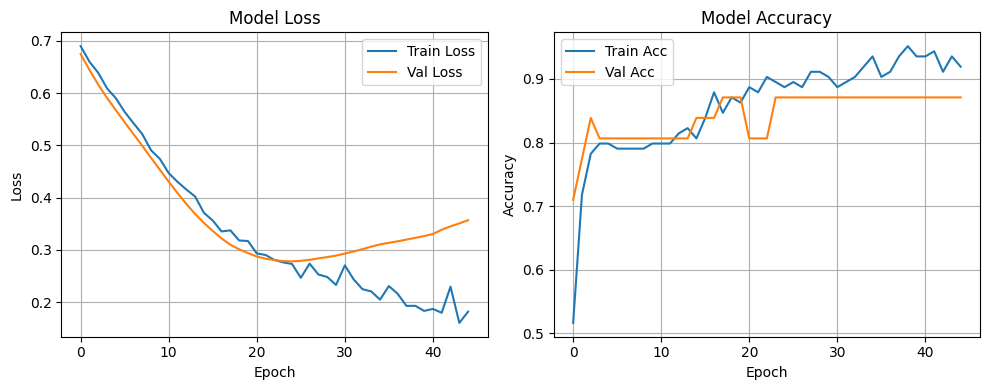

In [ ]:
# @title Step 9: Visualize training
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# ------------------------------------------------------------------
# Plot 1: Loss (Left Graph)
# ------------------------------------------------------------------
# Plot Training Loss if available
if 'train_loss' in class_history:
    ax1.plot(class_history['train_loss'], label='Train Loss')

# Plot Validation Loss
ax1.plot(class_history['val_loss'], label='Val Loss')

ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# ------------------------------------------------------------------
# Plot 2: Accuracy (Right Graph)
# ------------------------------------------------------------------
# Plot Training Accuracy if available
if 'train_accuracy' in class_history:
    ax2.plot(class_history['train_accuracy'], label='Train Acc')

# Plot Validation Accuracy
ax2.plot(class_history['val_accuracy'], label='Val Acc')

ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

# Show the plots
plt.tight_layout()
plt.show()

If your code is correct you should see two side-by-side plots showing `Model Loss` on the left and `Model Accuracy` on the right. Each plot should have two curves, either `Train Loss` and `Val Loss` (left graph) or `Train Acc` and `Val Acc` (right graph).

## **Electronic Submission**

In BIO 1173, assignments are basically **coding exams**. You will not know what score you will receive for `Assignment_01` until **after** you submit.

#### **WARNING:** YOU CAN ONLY SUBMIT YOUR ASSIGNMENT ONCE!

Don't submit your Assignment_01 unless you are sure you are ready to have it graded. You will not be given a second chance to make any corrections.  

In [ ]:
# @title  Electronic Submission

import urllib.request
import ssl
import time

url = "https://biologicslab.co/BIO1173/backend_code/validate_assignment.py?v=" + str(time.time())

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

req = urllib.request.Request(
    url,
    headers={
        "Cache-Control": "no-cache, no-store, must-revalidate",
        "Pragma": "no-cache",
        "Expires": "0"
    }
)

with urllib.request.urlopen(req, context=ctx) as r:
    exec(r.read().decode("utf-8"))

main()

Credentials Check
UTSA ID  ✅
API Key  ✅
Notebook: ASSIGNMENT_01
Notebook collected ✅  (184,453 bytes)

⚠️  Assignments are one-shot — this run submits your notebook.
Submitting for grading — this may take a moment…
✅  Submission received  (ID: BIO1173_6ab1bcb4d0842)

  Final Submission Score Report

  Exercise      Score   Output  Status
  --------------------------------------------
  ✅  Exercise Step 1: Download and Extract Data  100%   [text]   correct
  ✅  Exercise Step 2: Print summary statistics  100%   [text]   correct
  ✅  Exercise Step 3: Find missing values  100%   [text]   correct
  ✅  Exercise Step 4: Replace missing values  100%   [text]   correct
  ✅  Exercise Step 5: Display data types  100%   [text]   correct
  ✅  Exercise Step 6: One-Hot Encode Categorical Variables  100%   [text]   correct
  ✅  Exercise Step 7: Create feature vector for classification neural network  100%   [text]   correct
  ✅  Exercise Step 8: Construct and Train Classification Neural Network  100% 